# 05 — Remote Work Trends

Work modality distribution and remote work patterns across roles. Explores how fully remote, hybrid, and on-site arrangements are distributed across job families, seniority levels, and language requirements.

In [1]:
from analysis.utils import notebook_init

df = notebook_init()

Loaded 19,148 rows × 29 columns


In [2]:
from analysis import charts as _charts
from analysis.charts import horizontal_bar, stacked_bar
from analysis.filters import explode_json_col

df.head(3)

,row_id,job_url,date_posted,company_name,city,state,title,title_cleaned,job_family,job_summary,...,nice_to_have_skills,benefits,tasks,languages,benefit_categories,soft_skill_categories,description_quality,site,validation_flags,description
0,c3b86e465187,https://de.linkedin.com/jobs/view/softwareentw...,2025-11-17,HMS Analytical Software | Consulting & End-to-...,Heidelberg,Baden-Württemberg,Softwareentwickler / Data Engineer DevOps (mwd),Software Developer / Data Engineer DevOps,Data Engineer,Software Developer / Data Engineer DevOps crea...,...,"[""AWS"", ""Azure"", ""Scripting Languages""]","[""Flexible working hours"", ""Mobile Office / hy...","[""Create, extend and operate innovative, perfo...",[],"[""compensation"", ""education"", ""flexible_hours""...","[""Communication"", ""Customer Focus"", ""Teamwork""]",concatenated,linkedin,[],Unsere über 30-jährige Erfolgsgeschichte im So...
1,a85937eee245,https://de.linkedin.com/jobs/view/werkstudent-...,2025-12-17,HMS Analytical Software | Consulting & End-to-...,Heidelberg,Baden-Württemberg,"Werkstudent (mwd) Data Analytics, BI & Reporting","Working Student Data Analytics, BI & Reporting",Working Student,"Working student supporting data analytics, BI,...",...,"[""MS PowerBI""]","[""Flexible working hours"", ""Mobile Office/hybr...","[""Building and maintaining modern data pipelin...",[],"[""education"", ""flexible_hours"", ""food"", ""healt...","[""Teamwork""]",concatenated,linkedin,"[{""field"": ""contract_type"", ""rule"": ""intern_co...",Unsere über 35-jährige Erfolgsgeschichte im So...
2,afa0059eab62,https://de.linkedin.com/jobs/view/system-admin...,2026-01-16,NZR Nordwestdeutsche Zählerrevision Ing. Aug. ...,Bad Laer,Lower Saxony,System-Administrator (m/w/d),System-Administrator,System Administrator,System administrator responsible for maintaini...,...,"[""InforCom ERP""]","[""29 vacation days"", ""Flexible working hours"",...","[""Ensuring smooth IT operations across entire ...",[],"[""education"", ""flexible_hours"", ""health"", ""mob...","[""Structured Work"", ""Teamwork""]",concatenated,linkedin,"[{""field"": ""technical_skills"", ""rule"": ""skill_...",Ihre Vorteile bei NZR:Ein attraktives Gehalt i...


## Work Modality Split

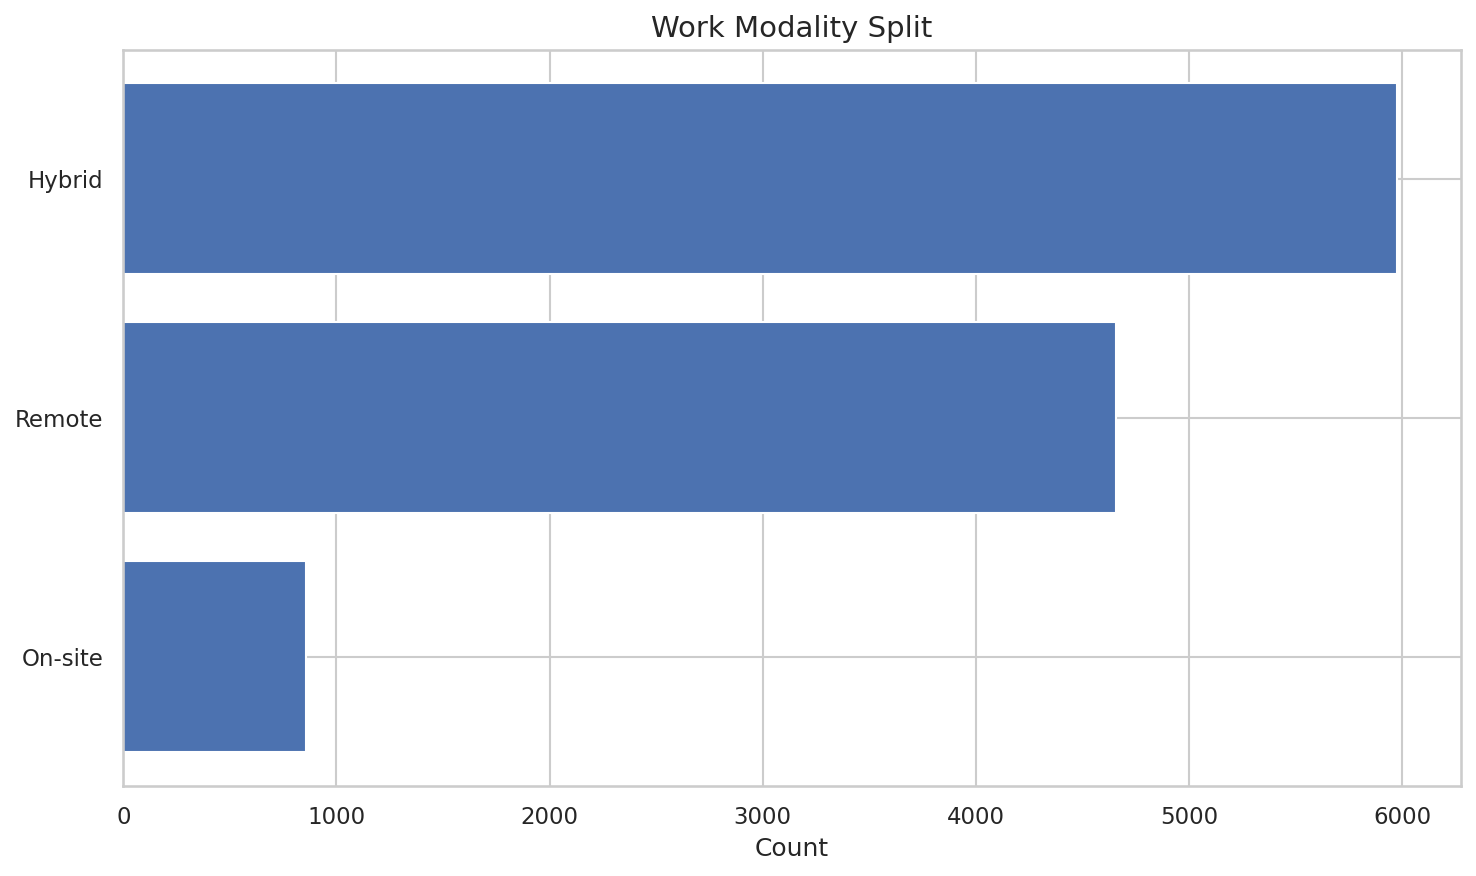

In [3]:
horizontal_bar(
    df["work_modality"],
    "Work Modality Split",
    save_as="05_modality.png",
)

## Remote Work by Job Family

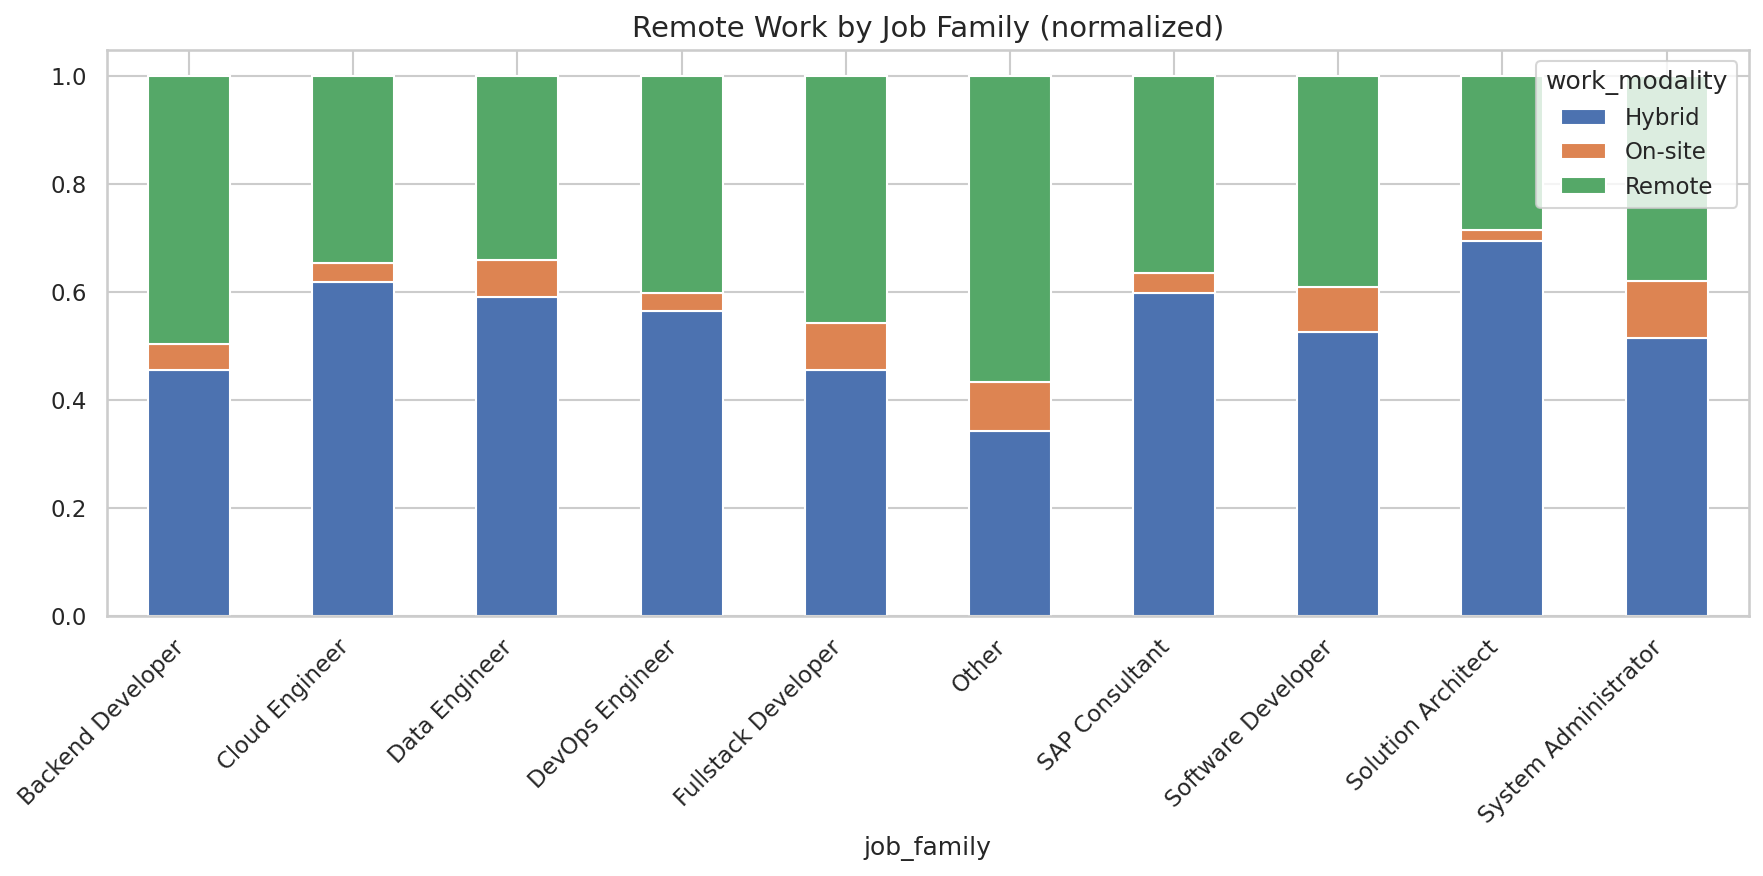

In [4]:
import pandas as pd

top_families = df["job_family"].value_counts().head(10).index
ct = pd.crosstab(
    df[df["job_family"].isin(top_families)]["job_family"],
    df[df["job_family"].isin(top_families)]["work_modality"],
    normalize="index",
)
stacked_bar(ct, "Remote Work by Job Family (normalized)", save_as="05_remote_family.png")

## Remote Work by Seniority

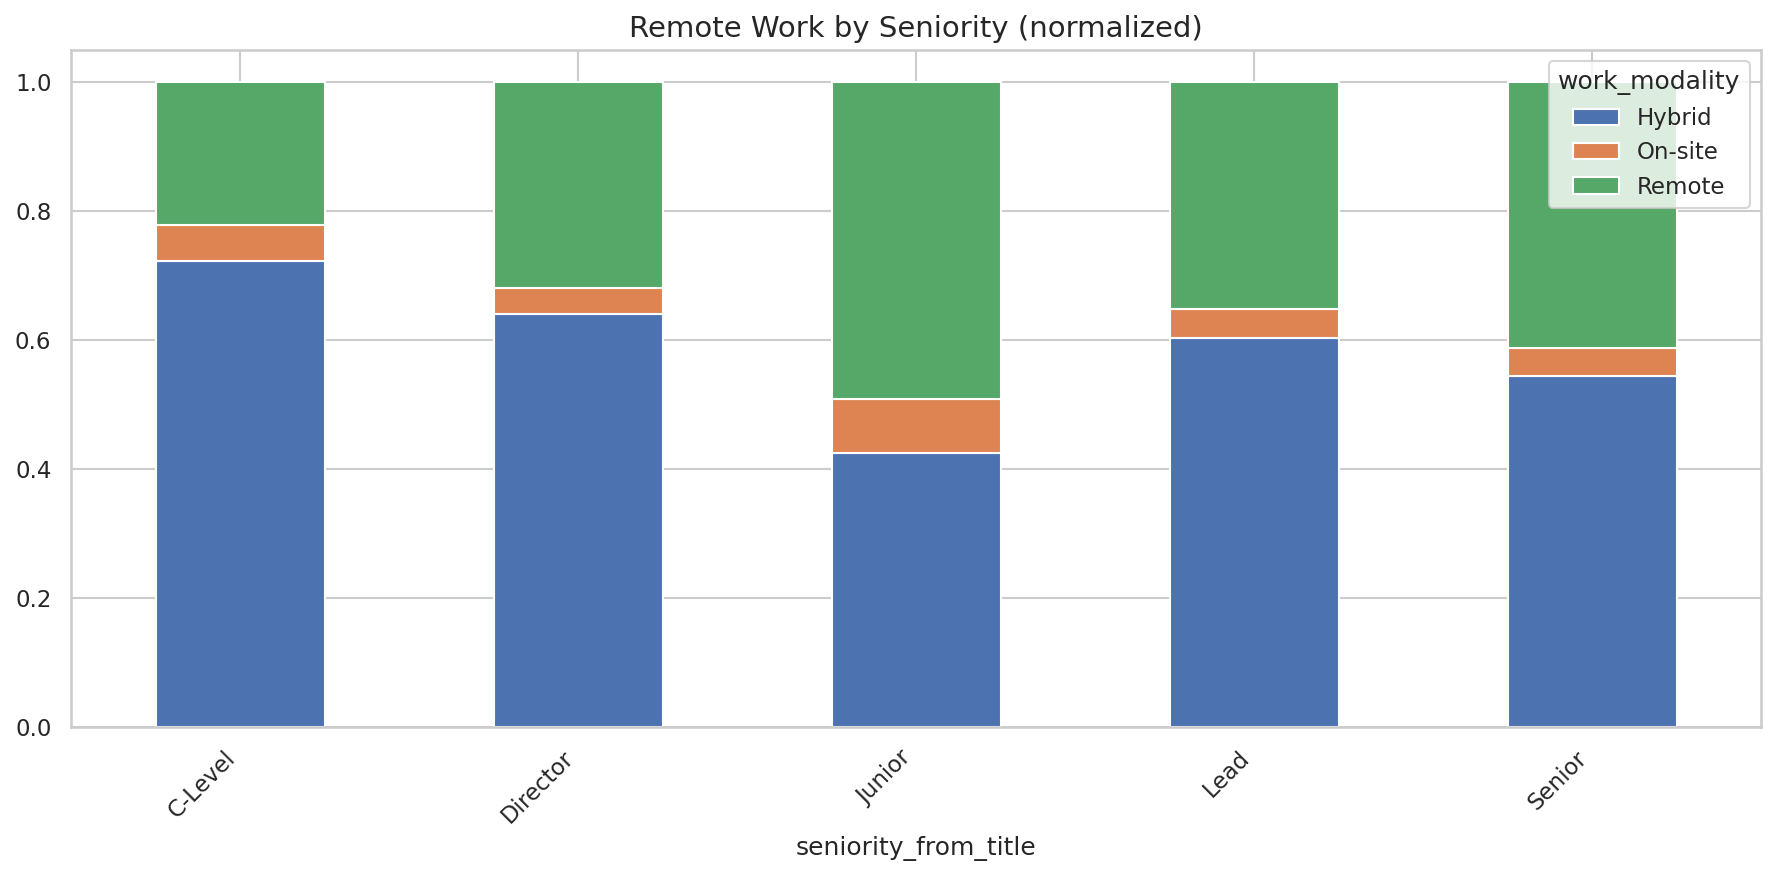

In [5]:
ct_seniority = pd.crosstab(
    df["seniority_from_title"],
    df["work_modality"],
    normalize="index",
)
stacked_bar(ct_seniority, "Remote Work by Seniority (normalized)", save_as="05_remote_seniority.png")

## Language Requirements x Remote

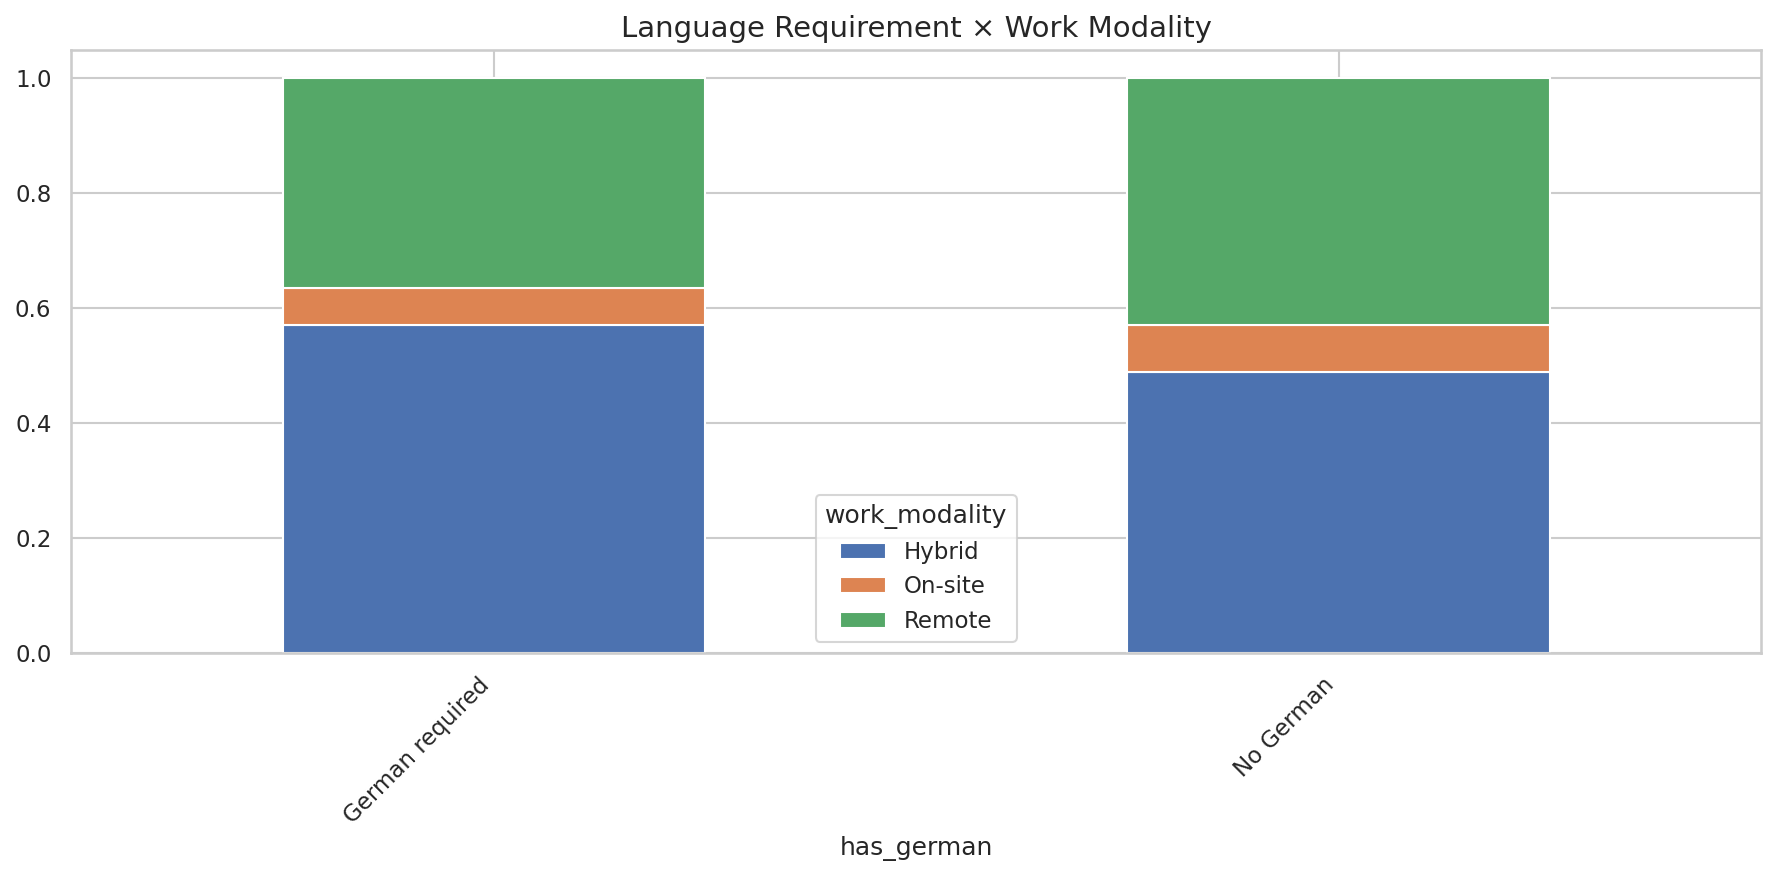

In [6]:
import json

def has_german(lang_json: object) -> bool:
    try:
        langs = json.loads(str(lang_json))
        return any(
            isinstance(lang, dict) and lang.get("language", "").lower() == "german"
            for lang in langs
        )
    except (json.JSONDecodeError, TypeError):
        return False

df2 = df.copy()
df2["has_german"] = df2["languages"].apply(has_german)
ct_lang = pd.crosstab(df2["has_german"].map({True: "German required", False: "No German"}), df2["work_modality"], normalize="index")
stacked_bar(ct_lang, "Language Requirement × Work Modality", save_as="05_lang_modality.png")